# Experiment 1a — does Autostep hold useless connections down?

**Problem.** Stationary 2-task multi-GEOFF: two independent GEOFF teachers, each with 2 inputs and
1 output, plus $N(0, 1)$ observation noise. Inputs and outputs are laid out task-major, and the
loss is a plain sum of per-output squared errors, so nothing about the grouping leaks through the
loss. Training is online, one fresh sample per step. Per-output MSE is 1.0 for an optimal predictor
(the noise variance) and 2.0 for the mean predictor.

**Network.** A two-layer MLP with 4 LTU hidden units — a step function forward with a
sigmoid-derivative surrogate backward, so the learner's units are the same kind as the teacher's.
Connectivity is a 0/1 mask multiplied into the weights: the base structure is block-sparse, each
hidden unit wired only to its own task's inputs and outputs, and on top of it half of the hidden
units are additionally wired to *every* other-task output, the other half to every other-task
input. Each of those extra connections crosses tasks and so is **useless by construction**; that
useful/useless split is what the figures measure. Each layer also gets a constant-1 input column,
so biases are ordinary weights inside the weight matrix, which is what Autostep's per-output-unit
normalizer needs. Input weights start uniform on `INIT_W1_RANGE`; output weights and
biases start at 0, except in the fixed-feedback run, where every weight starts at 0 (see below).

**Runs.** SGD + momentum at one static step-size (nothing but $|w|$ can separate the groups),
Autostep variant B (normalize by the squared value of each weight's source unit), variant B with a
fast bias, variant B with a fast bias and an L1 penalty, and that last one again with fixed
feedback (below). `L1_MODE` picks whether the penalty is
a subgradient inside the gradient Autostep adapts on, so it shapes the step-sizes too, or a proximal
soft-threshold applied after the update, which Autostep never sees. Under Autostep every connection
starts at step-size `INIT_LR`: useful ones should climb off it, useless ones should stay near it. The
fast-bias runs start each layer's bias column at `INIT_BIAS_LR` instead. While an output still has a
mean error, every 0/1 hidden unit feeding it gets a consistently signed gradient and acts as a
partial bias, cross-task units included, so their step-sizes climb too; a bias that absorbs the mean
before that can happen removes the confound.

**Fixed feedback.** In the fixed-feedback run the gradient reaching the input layer does not go
through `w2`. A random $\pm 1$ matrix on the output layer's connectivity, drawn once per run and
never trained, stands in for `w2` on the way back, so the input layer's learning signal is not tied
to whatever `w2` happens to be, and does not vanish while `w2` is still 0. `w2` itself gets its
ordinary gradient, and the forward pass is unchanged. That run therefore starts *every* weight at
0, `w1` included, as the method was originally run. Every other run uses plain backpropagation.

In [1]:
import os
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from phd.jax_core.optimizers.idbd import optax_idbd
from phd.jax_core.tasks.multi_geoff import MultiGEOFFTask
from phd.jax_core.utils import stack_pytrees, tree_replace
from phd.research_utils.analysis.analysis_utils import get_color_palette

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:      # make the sibling modules importable
    sys.path.insert(0, NOTEBOOK_DIR)

from masked_mlp import (
    BIAS, USEFUL, USELESS, MaskedTwoLayerMLP, block_sparse_masks, connection_labels,
    contaminate_masks, gather_at, halves_group_ids, penalty_masks, slot_ids, subsample_indices,
)

sns.set_theme('notebook', 'white')
%matplotlib inline

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an 

In [ ]:
# --- Problem ---
N_TASKS = 2
N_FEATURES_PER_TASK = 2
N_OUTPUTS_PER_TASK = 1
NOISE_STD = 1.0

# --- Network ---
N_HIDDEN = 4
ACTIVATION = 'ltu'
USE_BIAS = True
INIT_W1_RANGE = (-0.0001, 0.0001)      # input weights ~ U(range); output weights and biases at 0

# --- Optimizers ---
INIT_LR = 1e-8                   # starting step-size of every connection under Autostep ...
INIT_BIAS_LR = 2 ** -4           # ... except the bias columns in the fast-bias runs, which start here
META_LR = 0.02
L1_MODE = 'subgradient'          # 'subgradient': L1 enters the gradient Autostep adapts on;
                                 # 'proximal': soft-threshold after the update, unseen by Autostep
L1_COEFF = 0.01
SGD_LR = 0.0005                   # tuned so the effective step-size lr / (1 - momentum) stays stable
SGD_MOMENTUM = 0.9

# --- Training and recording ---
NUM_STEPS = 1_000_000
N_SEEDS = 30                     # vmapped into one scan; scan width is nearly free
N_SNAPSHOTS = 250                # recording points per run, for both the loss and the connections
N_TRACES = 30                    # individual connections followed per layer per group
BASE_SEED = 0

# --- Derived ---
N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK
IRREDUCIBLE_MSE = NOISE_STD ** 2         # per-output MSE of an optimal predictor
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0     # the mean predictor sits 1 above it
LAYERS = ('w1', 'w2')
LAYER_NAMES = ('input layer (hidden $\\leftarrow$ inputs)',
               'output layer (outputs $\\leftarrow$ hidden)')
GROUPS = (USEFUL, USELESS, BIAS)         # biases belong to no task; plotted for reference
GROUP_NAMES = ('useful (same task)', 'useless (cross task)', 'bias')
GROUP_COLORS = ('#3b6fb0', '#c0392b', '#27ae60')
SGD_LABEL = f'SGD + momentum (lr {SGD_LR:g}, m {SGD_MOMENTUM:g})'
FAST_BIAS_LABEL = f'fast bias ($\\alpha_0$ = {INIT_BIAS_LR:g})'
FEEDBACK_LABEL = 'fixed $\\pm 1$ feedback'

In [3]:
base_masks, hidden_task_ids = block_sparse_masks(
    N_TASKS, N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK, N_HIDDEN, bias=USE_BIAS)
input_task_ids = slot_ids(N_TASKS, N_FEATURES_PER_TASK)
output_task_ids = slot_ids(N_TASKS, N_OUTPUTS_PER_TASK)

# Contaminate: half the hidden units gain every cross-task output, the other half every cross-task
# input. Labels mark each position useful / useless / bias, and never change during a run.
masks = contaminate_masks(base_masks, hidden_task_ids, halves_group_ids(hidden_task_ids),
                          input_task_ids, output_task_ids)
labels = connection_labels(masks, hidden_task_ids, input_task_ids, output_task_ids)
l1_masks = penalty_masks(masks, bias=USE_BIAS)      # what L1 pulls on: everything but the biases

# Which individual connections the figures follow. Fixed once, outside `jit`.
trace_idxs = {l: {g: subsample_indices(labels[l], g, N_TRACES, seed=BASE_SEED) for g in GROUPS}
              for l in LAYERS}

for layer in LAYERS:
    counts = '   '.join(f'{name} {int((labels[layer] == g).sum()):3d}'
                        for g, name in zip(GROUPS, GROUP_NAMES))
    print(f'{layer}:  {counts}')

w1:  useful (same task)   8   useless (cross task)   4   bias   4
w2:  useful (same task)   4   useless (cross task)   2   bias   2


## Learner

In [4]:
class FixedFeedbackMLP(MaskedTwoLayerMLP):
    """`MaskedTwoLayerMLP` whose backward pass through the output layer uses fixed +-1 weights.

    The forward pass is unchanged. On the way back, `feedback`, a random +-1 matrix on the output
    layer's connectivity that is drawn once and never trained, stands in for `w2`. The input layer's
    gradient therefore neither vanishes while `w2` is 0 nor follows whatever `w2` happens to be.
    `w2`'s own gradient is the ordinary one.
    """
    feedback: jax.Array

    def __init__(self, masks, feedback, **kwargs):
        super().__init__(masks, **kwargs)
        self.feedback = feedback

    def __call__(self, x):
        x = self._with_bias(x)
        hidden = self._with_bias(
            self.activation_fn((self.weights['w1'] * self.masks['w1']) @ x))
        w2 = self.weights['w2'] * self.masks['w2']
        # Value: w2 @ hidden. Gradient w.r.t. w2: hidden, as usual. Gradient w.r.t. hidden: feedback.
        output = (w2 @ jax.lax.stop_gradient(hidden)
                  + self.feedback @ hidden - jax.lax.stop_gradient(self.feedback @ hidden))
        return output, {'w1': x[None, :], 'w2': hidden[None, :]}


def random_feedback(key):
    """A random +-1 per output-layer connection. The bias column carries no gradient, so it is 0."""
    signs = jax.random.bernoulli(key, 0.5, masks['w2'].shape).astype(jnp.float32) * 2.0 - 1.0
    feedback = signs * masks['w2']
    return feedback.at[:, -1].set(0.0) if USE_BIAS else feedback


class Learner(eqx.Module):
    """The masked MLP and its optimizer: Autostep variant B, or SGD + momentum as the baseline.

    Masked-out connections are inert either way — the mask zeroes their loss gradient, so their
    weight and optimizer state never leave 0.

    With `fixed_feedback` the model is a `FixedFeedbackMLP`: the input layer's gradient comes
    through a fixed random +-1 matrix instead of `w2`, and the optimizer is untouched.
    """
    model: MaskedTwoLayerMLP
    opt_state: optax.OptState
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    autostep: bool = eqx.field(static=True)
    l1: float = eqx.field(static=True)

    def __init__(self, key, optimizer, autostep, l1=0.0, bias_init_lr=None, fixed_feedback=False):
        # Input weights uniform on `INIT_W1_RANGE`, output weights and biases at 0. Masked-out
        # positions are held at exactly 0, as `MaskedTwoLayerMLP`'s own init does. A zero output
        # layer only stalls the input layer for one step (variant B's normalizer does not go
        # through the prediction gradients, which a zero layer would kill).
        if fixed_feedback:
            # The fixed-feedback run starts every weight at 0, `w1` included, exactly as in its
            # original notebook (same key split too, so it reproduces those results). The other
            # runs keep drawing `w1` from `key` and are untouched.
            _, feedback_key = jax.random.split(key)
            model = FixedFeedbackMLP(masks, random_feedback(feedback_key), activation=ACTIVATION,
                                     bias=USE_BIAS, key=key)
            w1 = jnp.zeros_like(model.weights['w1'])
        else:
            model = MaskedTwoLayerMLP(masks, activation=ACTIVATION, bias=USE_BIAS, key=key)
            w1 = jax.random.uniform(key, model.weights['w1'].shape, minval=INIT_W1_RANGE[0],
                                    maxval=INIT_W1_RANGE[1])
        if USE_BIAS:
            w1 = w1.at[:, -1].set(0.0)
        self.model = tree_replace(model, weights={'w1': w1 * masks['w1'],
                                                  'w2': jnp.zeros_like(model.weights['w2'])})
        self.optimizer = optimizer

        opt_state = optimizer.init(self.model.weights)
        if autostep and USE_BIAS and bias_init_lr is not None:
            # Give the bias columns their own starting step-size. `init_beta` stays at `INIT_LR`;
            # it is only read when `shadow_weight_threshold_factor` is set, which it is not here.
            opt_state = opt_state._replace(beta={
                k: b.at[:, -1].set(jnp.log(bias_init_lr)) for k, b in opt_state.beta.items()})
        self.opt_state = opt_state
        self.autostep = autostep
        self.l1 = l1

    @property
    def step_sizes(self):
        """Per-connection step-sizes: adapted under Autostep, static under SGD."""
        if self.autostep:
            return {k: jnp.exp(self.opt_state.beta[k]) for k in LAYERS}
        return {k: jnp.full_like(w, SGD_LR) for k, w in self.model.weights.items()}

    def step(self, x, y):
        """One online update. Returns the new learner and the squared error summed over outputs."""
        def loss_fn(weights):
            out, param_inputs = tree_replace(self.model, weights=weights)(x)
            return jnp.sum((out - y) ** 2), param_inputs

        (loss, param_inputs), grads = jax.value_and_grad(loss_fn, has_aux=True)(self.model.weights)

        # `loss` stays pure squared error either way, so the MSE curves stay comparable across runs.
        # Biases are left out of the penalty: shrinking one fights the target's nonzero mean instead
        # of pruning structure.
        if self.l1 > 0.0 and L1_MODE == 'subgradient':
            # L1 goes into the gradient Autostep consumes, so it shapes step-size adaptation too.
            grads = {k: g + self.l1 * l1_masks[k] * jnp.sign(self.model.weights[k])
                     for k, g in grads.items()}

        # Variant B treats each layer as its own linear problem, normalizing by the squared value of
        # each weight's source unit — which is exactly the `param_inputs` the forward pass returns.
        update_input = (grads, None, param_inputs) if self.autostep else grads
        updates, opt_state = self.optimizer.update(update_input, self.opt_state, self.model.weights)
        weights = {k: w + updates[k] for k, w in self.model.weights.items()}
        new = tree_replace(self, model=tree_replace(self.model, weights=weights), opt_state=opt_state)

        if self.l1 > 0.0 and L1_MODE == 'proximal':
            # Soft-threshold by each weight's own step-size times `l1`: the same pull per step as the
            # subgradient, but applied after the optimizer, so Autostep never sees it, and a weight
            # the pull reaches is parked at exactly 0 instead of chattering across it.
            shrink = {k: self.l1 * l1_masks[k] * a for k, a in new.step_sizes.items()}
            weights = {k: jnp.sign(w) * jnp.maximum(jnp.abs(w) - shrink[k], 0.0)
                       for k, w in weights.items()}
            new = tree_replace(new, model=tree_replace(new.model, weights=weights))
        return new, loss


def autostep_learner(key, l1=0.0, bias_init_lr=None, fixed_feedback=False):
    return Learner(key, optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True,
                                   version='squared_inputs'), autostep=True, l1=l1,
                   bias_init_lr=bias_init_lr, fixed_feedback=fixed_feedback)


def sgd_learner(key):
    return Learner(key, optax.sgd(SGD_LR, momentum=SGD_MOMENTUM), autostep=False)

## Training

In [5]:
def snapshot(learner):
    """Step-size and weight of the traced connections, shaped (layer, group, trace)."""
    def traces(values):
        return jnp.stack([jnp.stack([gather_at(values[l], trace_idxs[l][g]) for g in GROUPS])
                          for l in LAYERS])

    return {'alpha': traces(learner.step_sizes),
            'w': traces(learner.model.weights)}


def train(learner, task):
    """`NUM_STEPS` of online training.

    Returns every step's loss, `N_SNAPSHOTS` + 1 connection snapshots, and the number of times each
    weight changed sign. Sign changes are counted every step, since they are invisible to snapshots.
    """
    def one_step(carry, _):
        learner, task, last_sign, crossings = carry
        task, (x, y) = task.generate_batch(1)              # online: one sample per step
        learner, loss = learner.step(x[0], y[0])
        # A crossing is a nonzero weight whose sign differs from its last nonzero sign, so a weight
        # that proximal L1 parks at exactly 0 on the way across still counts once, and a weight
        # leaving its zero initialization does not count at all.
        sign = {k: jnp.sign(w) for k, w in learner.model.weights.items()}
        crossings = {k: c + ((sign[k] != 0) & (last_sign[k] != 0) & (sign[k] != last_sign[k]))
                     .astype(c.dtype) for k, c in crossings.items()}
        last_sign = {k: jnp.where(sign[k] != 0, sign[k], last_sign[k]) for k in sign}
        return (learner, task, last_sign, crossings), loss

    def block(carry, _):
        snap = snapshot(carry[0])                          # start-of-block, so step 0 is recorded
        carry, losses = jax.lax.scan(one_step, carry, length=NUM_STEPS // N_SNAPSHOTS)
        return carry, (losses, snap)

    last_sign = {k: jnp.sign(w) for k, w in learner.model.weights.items()}
    crossings = {k: jnp.zeros_like(w) for k, w in learner.model.weights.items()}
    carry, (losses, snaps) = jax.lax.scan(block, (learner, task, last_sign, crossings),
                                          length=N_SNAPSHOTS)
    # Snapshots then run 0, ..., NUM_STEPS once the final state is appended.
    snaps = jax.tree.map(lambda s, final: jnp.concatenate([s, final[None]]), snaps,
                         snapshot(carry[0]))
    return losses, snaps, carry[3]


def run(make_learner):
    """Train `N_SEEDS` independent runs — one teacher and one init each — vmapped into one scan."""
    tasks = stack_pytrees([                                # the task takes an int seed, not a key
        MultiGEOFFTask(N_TASKS, n_features_per_task=N_FEATURES_PER_TASK,
                       n_outputs_per_task=N_OUTPUTS_PER_TASK, noise_std=NOISE_STD,
                       seed=BASE_SEED + s)
        for s in range(N_SEEDS)])
    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), N_SEEDS)
    losses, snaps, crossings = jax.jit(
        jax.vmap(lambda key, task: train(make_learner(key), task)))(keys, tasks)

    # Per-output MSE, averaged within each block; snapshots sit on the block edges.
    block_len = NUM_STEPS // N_SNAPSHOTS
    return {'steps': np.arange(1, N_SNAPSHOTS + 1) * block_len,
            'snap_steps': np.arange(N_SNAPSHOTS + 1) * block_len,
            'mse': np.asarray(losses, dtype=np.float32).mean(-1) / N_OUTPUTS,
            'crossings': {k: np.asarray(v) for k, v in crossings.items()},
            **{k: np.asarray(v) for k, v in snaps.items()}}


runs = {
    SGD_LABEL: run(sgd_learner),
    'Variant B': run(autostep_learner),
    f'Variant B, {FAST_BIAS_LABEL}': run(
        lambda key: autostep_learner(key, bias_init_lr=INIT_BIAS_LR)),
    f'Variant B + {L1_MODE} L1 {L1_COEFF:g}, {FAST_BIAS_LABEL}': run(
        lambda key: autostep_learner(key, l1=L1_COEFF, bias_init_lr=INIT_BIAS_LR)),
    f'Variant B + {L1_MODE} L1 {L1_COEFF:g}, {FAST_BIAS_LABEL}, {FEEDBACK_LABEL}': run(
        lambda key: autostep_learner(key, l1=L1_COEFF, bias_init_lr=INIT_BIAS_LR,
                                     fixed_feedback=True)),
}

## Results

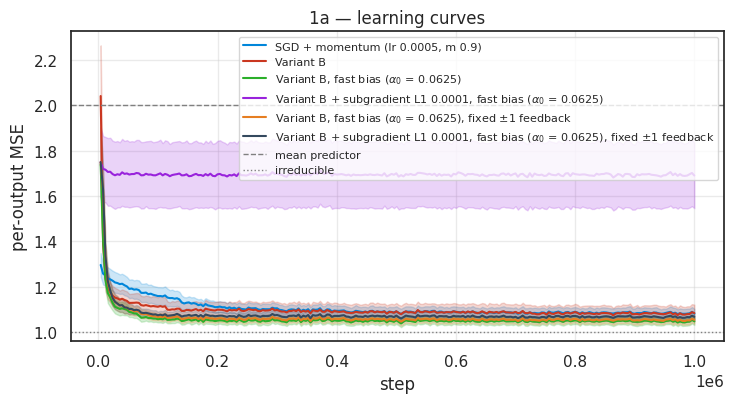

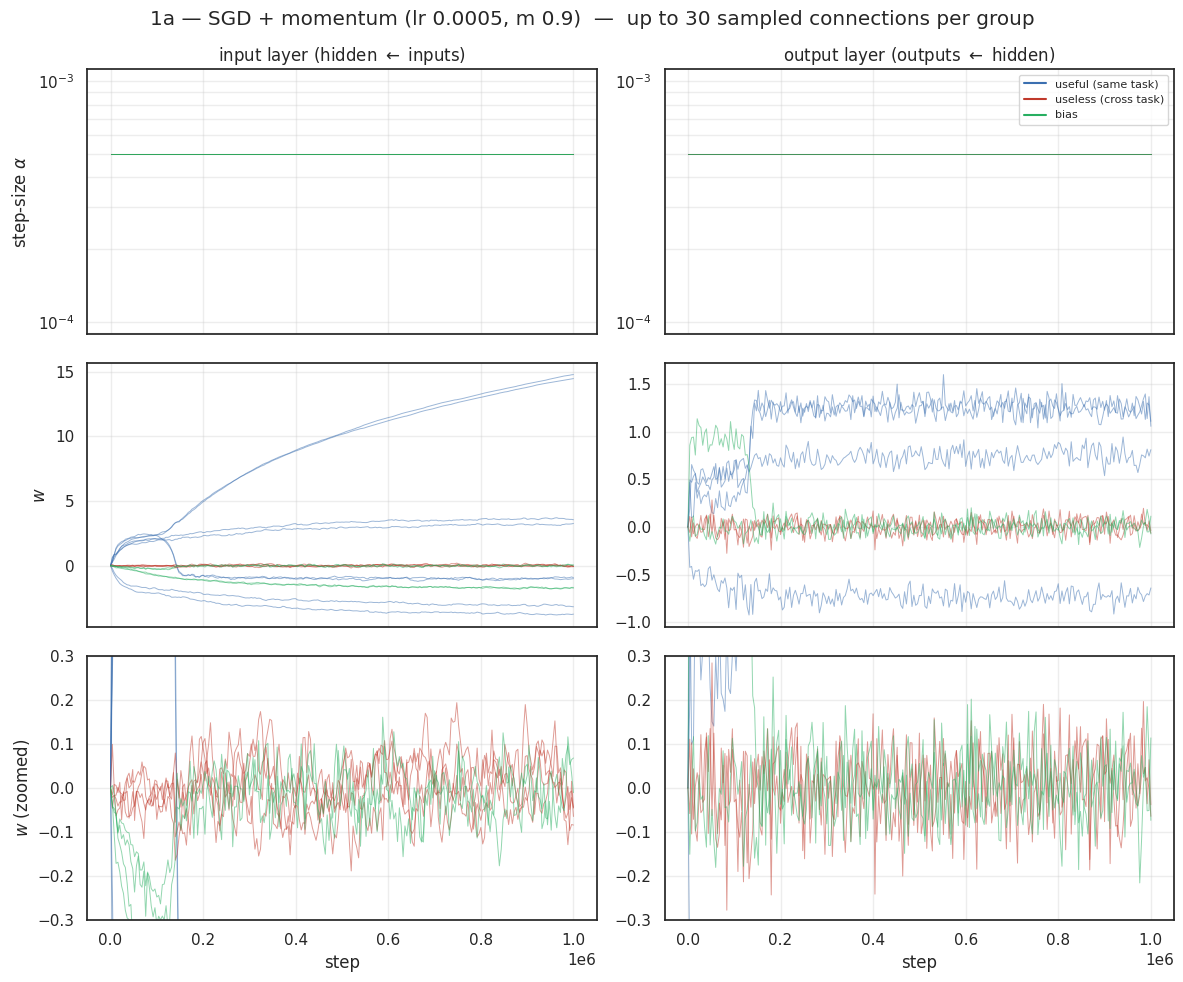

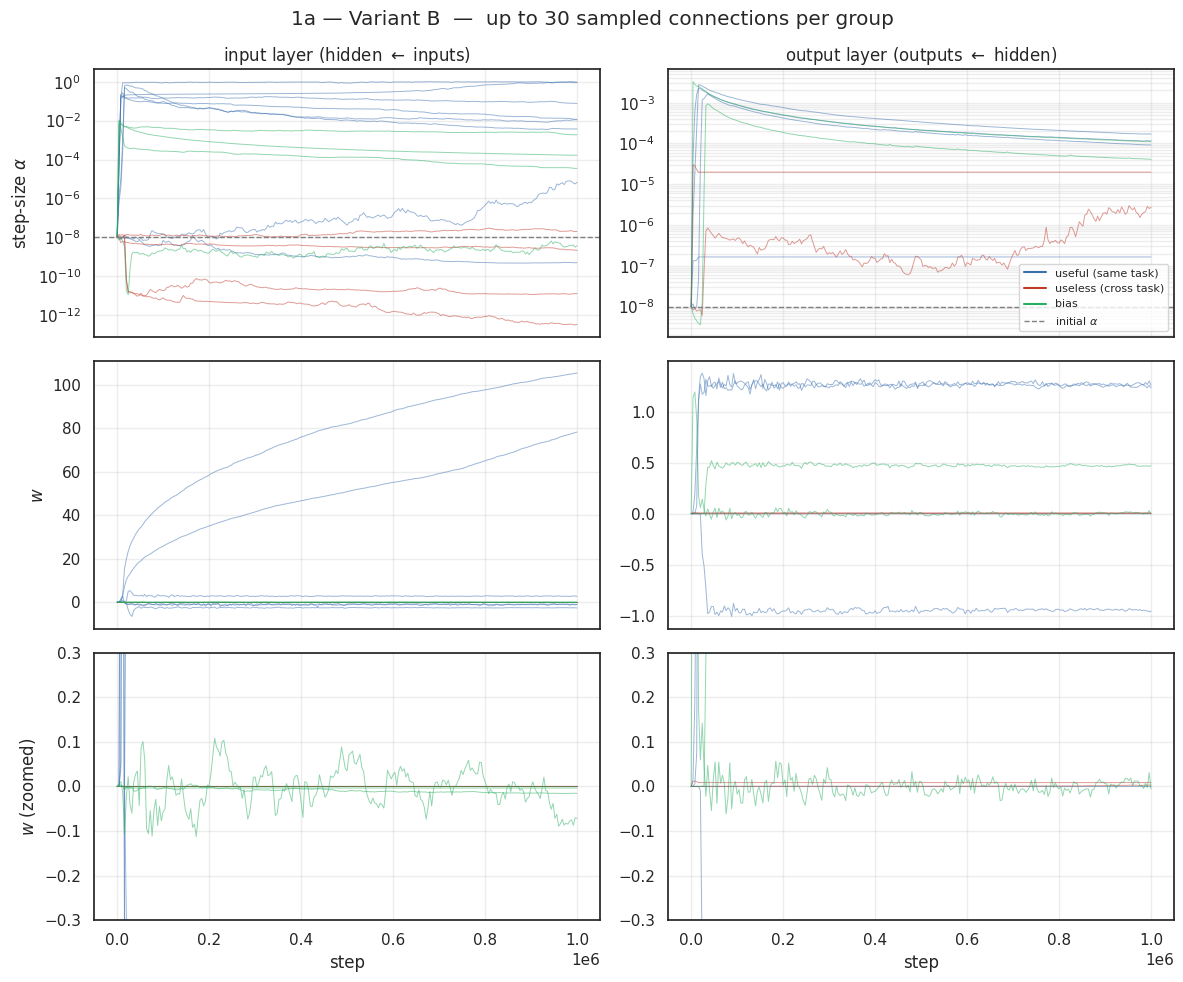

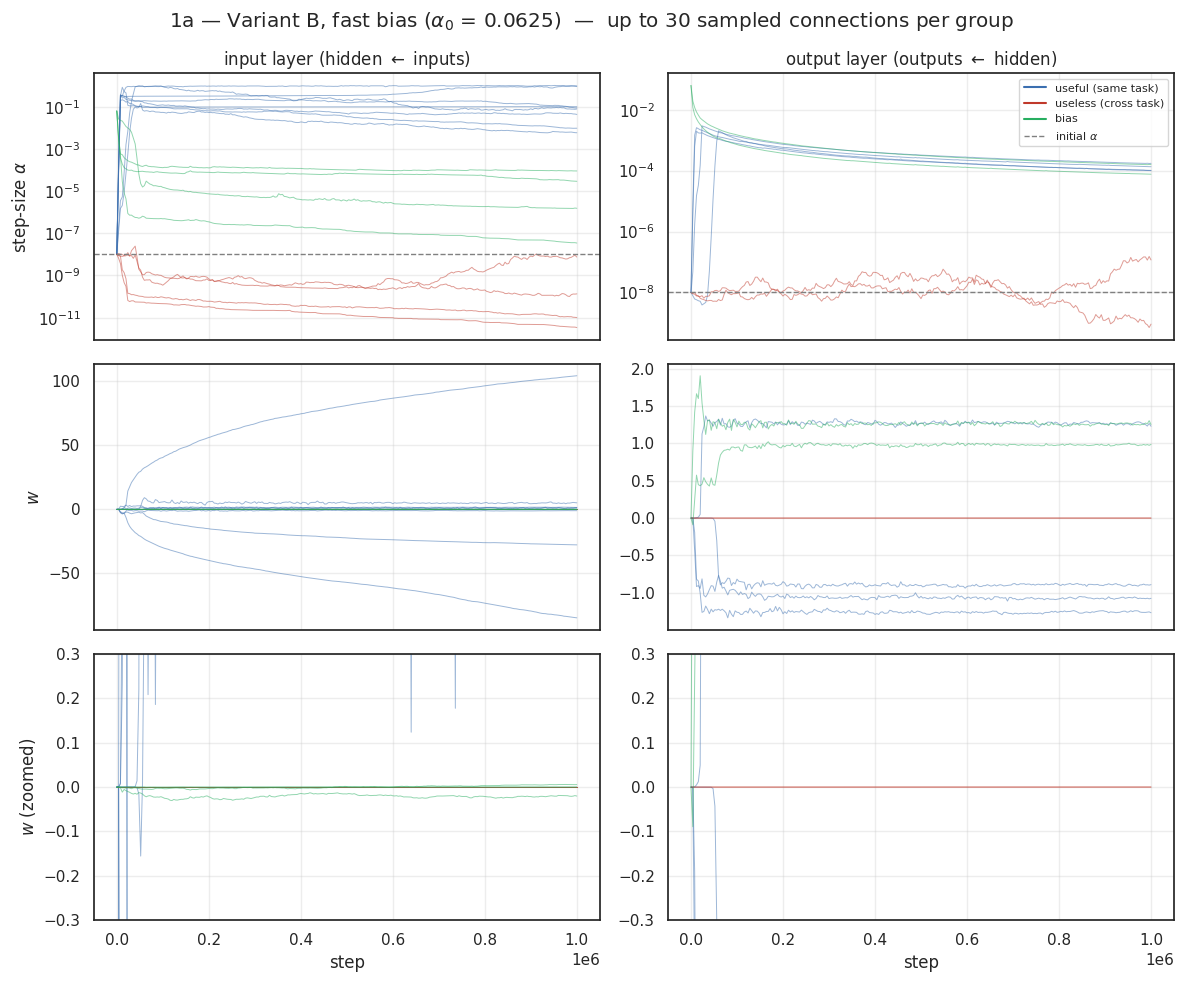

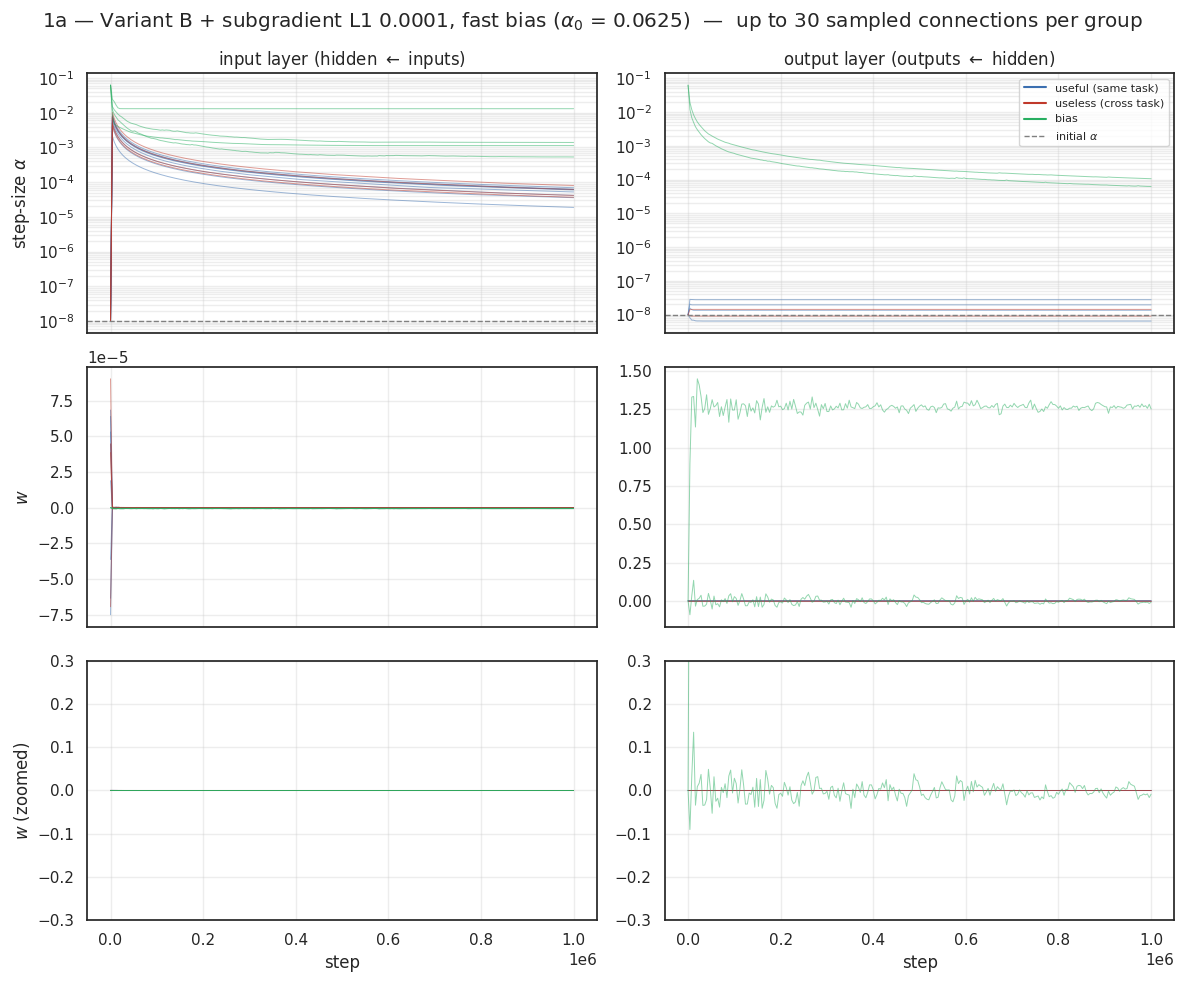

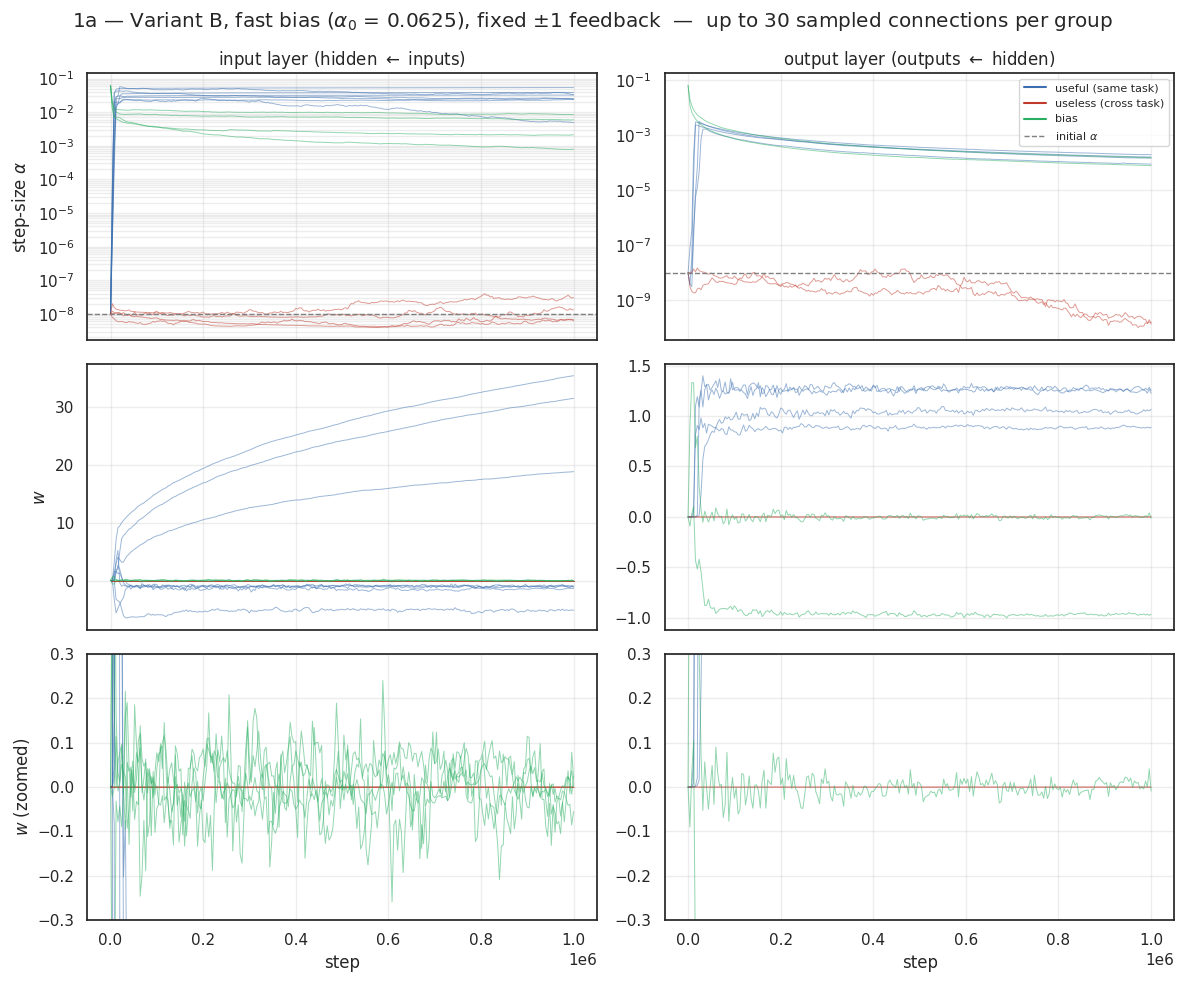

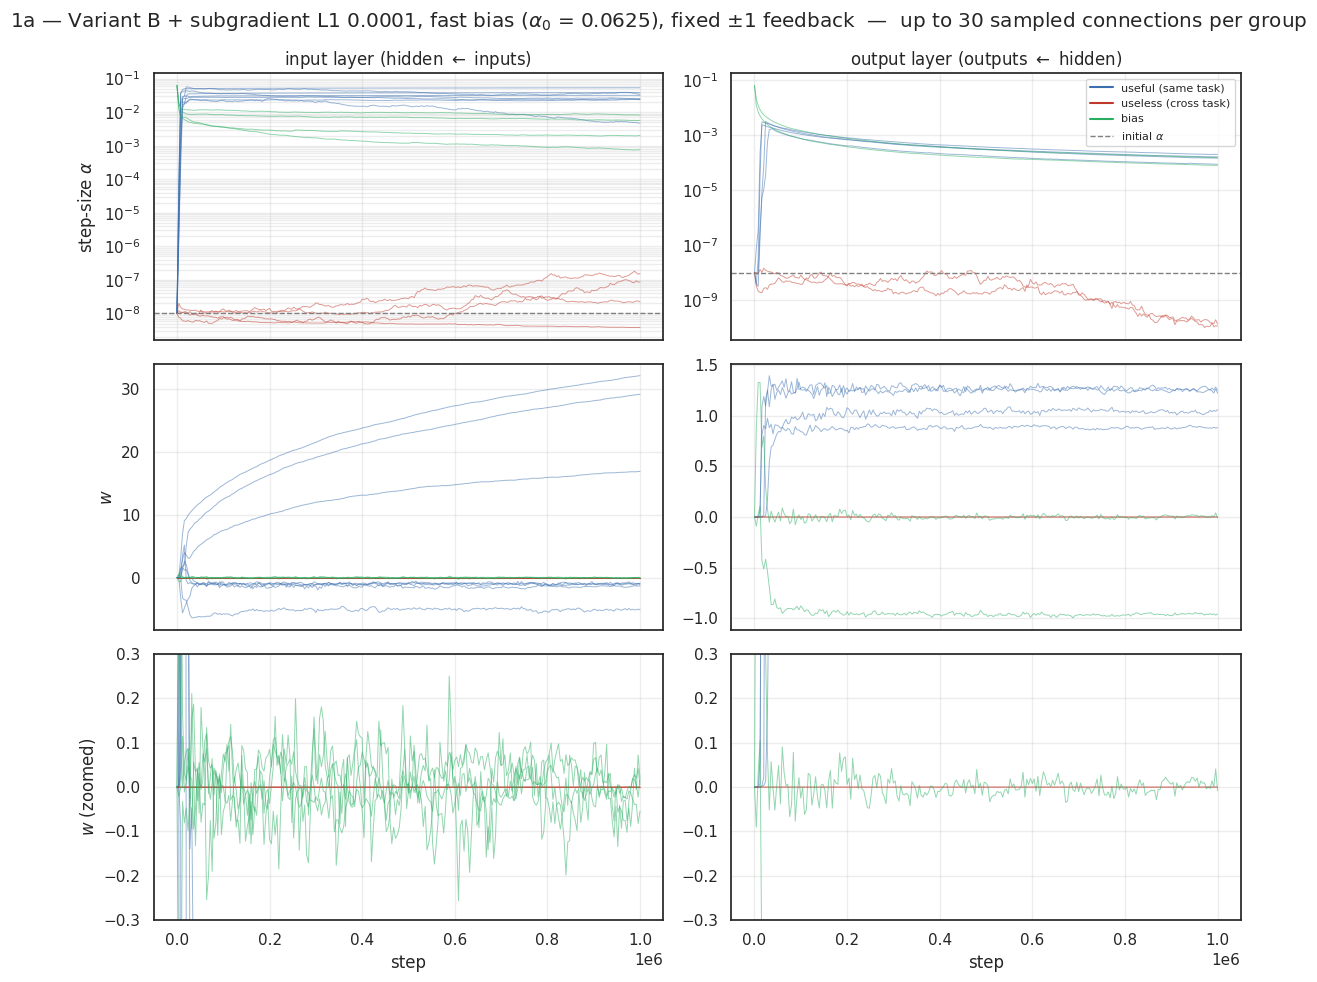

In [6]:
def plot_curves(runs):
    """Per-output MSE per run, mean +- 2 standard errors over seeds."""
    plt.figure(figsize=(7.5, 4.2))
    for (label, res), color in zip(runs.items(), get_color_palette(n=len(runs))):
        mean = res['mse'].mean(0)
        sem = res['mse'].std(0) / np.sqrt(N_SEEDS)
        plt.plot(res['steps'], mean, color=color, label=label)
        plt.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)
    plt.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor')
    plt.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible')
    plt.xlabel('step')
    plt.ylabel('per-output MSE')
    plt.title('1a — learning curves')
    plt.grid(alpha=0.4)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_connections(res, title, alpha_ref=INIT_LR):
    """One run's traced connections: step-size, weight, and weight zoomed in. One column per layer.

    `alpha_ref` marks where step-size adaptation started, and is None for SGD, which does not adapt.
    """
    rows = [('alpha', 'step-size $\\alpha$', True, None),
            ('w', '$w$', False, None),
            ('w', '$w$ (zoomed)', False, (-0.3, 0.3))]
    fig, axes = plt.subplots(len(rows), 2, figsize=(12, 10), sharex=True)
    for row, (key, ylabel, log_scale, ylim) in enumerate(rows):
        for col, layer_name in enumerate(LAYER_NAMES):
            ax = axes[row, col]
            for group, (name, color) in enumerate(zip(GROUP_NAMES, GROUP_COLORS)):
                ax.plot(res['snap_steps'], res[key][0, :, col, group], color=color, lw=0.7,
                        alpha=0.5)
                ax.plot([], [], color=color, lw=1.5, label=name)      # legend proxy
            if log_scale:
                ax.set_yscale('log')
                if alpha_ref is not None:
                    ax.axhline(alpha_ref, ls='--', c='gray', lw=1, label='initial $\\alpha$')
            if ylim is not None:
                ax.set_ylim(*ylim)
            ax.grid(alpha=0.35, which='both')
            ax.set_title(layer_name if row == 0 else '')
            ax.set_xlabel('step' if row == len(rows) - 1 else '')
            ax.set_ylabel(ylabel if col == 0 else '')
    axes[0, 1].legend(fontsize=8)
    fig.suptitle(f'1a — {title}  —  up to {N_TRACES} sampled connections per group')
    fig.tight_layout()
    plt.show()


plot_curves(runs)
for label, res in runs.items():
    plot_connections(res, label, alpha_ref=None if label == SGD_LABEL else INIT_LR)

In [7]:
def print_zero_crossings(runs):
    """Median rate at which a useless weight changes sign, per layer, pooled over seeds and connections."""
    width = max(len(label) for label in runs)
    print('median zero crossings per step of a useless (cross-task) weight')
    for label, res in runs.items():
        cols = []
        for layer, name in zip(LAYERS, ('input', 'output')):
            useless = np.asarray(labels[layer] == USELESS)
            rate = res['crossings'][layer][:, useless] / NUM_STEPS            # (seed, connection)
            cols.append(f'{name} ({layer}): {np.median(rate):.2e}')
        print(f'  {label:<{width}}   ' + '   '.join(cols))


print_zero_crossings(runs)

median zero crossings per step of a useless (cross-task) weight
  SGD + momentum (lr 0.0005, m 0.9)                                                            input (w1): 1.04e-03   output (w2): 6.36e-03
  Variant B                                                                                    input (w1): 0.00e+00   output (w2): 2.00e-04
  Variant B, fast bias ($\alpha_0$ = 0.0625)                                                   input (w1): 0.00e+00   output (w2): 9.85e-05
  Variant B + subgradient L1 0.0001, fast bias ($\alpha_0$ = 0.0625)                           input (w1): 9.11e-01   output (w2): 6.09e-01
  Variant B, fast bias ($\alpha_0$ = 0.0625), fixed $\pm 1$ feedback                           input (w1): 0.00e+00   output (w2): 3.30e-05
  Variant B + subgradient L1 0.0001, fast bias ($\alpha_0$ = 0.0625), fixed $\pm 1$ feedback   input (w1): 0.00e+00   output (w2): 1.40e-05
